In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, filtfilt, butter
import datetime as dt


In [89]:
%pip install neurokit2
import neurokit2 as nk

duration = 10
fs = 1000

ecg_signal = nk.ecg_simulate(
    duration=duration,
    sampling_rate=fs,
    heart_rate=70,
    noise=0.25,
    random_state=1113
    )


Note: you may need to restart the kernel to use updated packages.


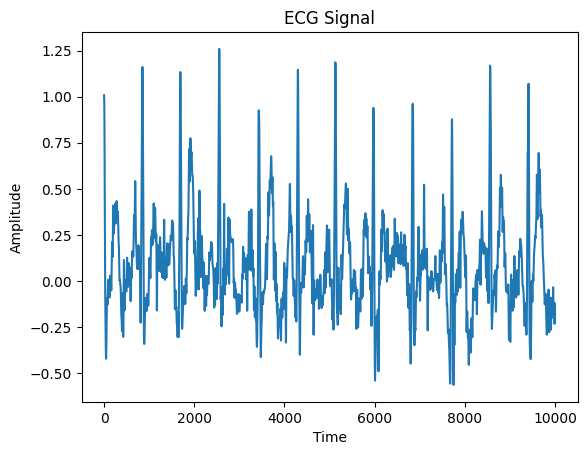

In [90]:
fig, ax = plt.subplots()
ax.plot(ecg_signal)
ax.set_title('ECG Signal')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
plt.show()

In [91]:
lowcut = 1 # Hz
highcut = 2.5 # Hz

In [92]:
nyquist_rata = fs/2
lowcut_nyquist = lowcut/nyquist_rata
highcut_nyquist = highcut/nyquist_rata
fft_order = 101

In [93]:
n = np.arange(0, fft_order)
M = (fft_order-1)//2

h_ideal = np.zeros(fft_order)

print(f"n = {n}\n M = {M}\n h_ideal = {h_ideal}")

n = [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100]
 M = 50
 h_ideal = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


In [94]:
for i in range(fft_order):
    if i == M:
        h_ideal[i] = 2*(highcut_nyquist - lowcut_nyquist)
    else:
        h_ideal[i] = (
            np.sin(2*np.pi*highcut_nyquist*(i-M))/np.pi*(i-M) 
            - np.sin(2*np.pi*lowcut_nyquist*(i-M))/(np.pi*(i-M))
            )
        
h = h_ideal * np.hamming(fft_order)
print(f"h = {h}")

h = [1.27294019 1.26100614 1.27489417 1.31255676 1.37172415 1.44993787
 1.54458569 1.65293756 1.7721821  1.89946327 2.0319168  2.16670591
 2.301056   2.43228793 2.55784948 2.67534475 2.78256102 2.87749312
 2.95836464 3.02364619 3.07207025 3.10264263 3.11465042 3.10766633
 3.08154954 3.03644292 2.9727669  2.89120985 2.79271543 2.67846675
 2.54986794 2.40852295 2.25621229 2.09486768 1.92654507 1.7533964
 1.57764035 1.40153254 1.22733543 1.05728844 0.89357846 0.73831133
 0.59348439 0.46096061 0.34244456 0.23946043 0.1533325  0.08516813
 0.03584362 0.00599302 0.006      0.00599302 0.03584362 0.08516813
 0.1533325  0.23946043 0.34244456 0.46096061 0.59348439 0.73831133
 0.89357846 1.05728844 1.22733543 1.40153254 1.57764035 1.7533964
 1.92654507 2.09486768 2.25621229 2.40852295 2.54986794 2.67846675
 2.79271543 2.89120985 2.9727669  3.03644292 3.08154954 3.10766633
 3.11465042 3.10264263 3.07207025 3.02364619 2.95836464 2.87749312
 2.78256102 2.67534475 2.55784948 2.43228793 2.301056   2.16

In [95]:
waktu_mulai = dt.datetime.now()
filtered_ecg = np.convolve(ecg_signal, h, mode='same')
waktu_selesai = dt.datetime.now()
waktu_proses = waktu_selesai - waktu_mulai
print(f"Proses filtering memakan waktu {waktu_proses.total_seconds()} detik")

Proses filtering memakan waktu 0.002074 detik


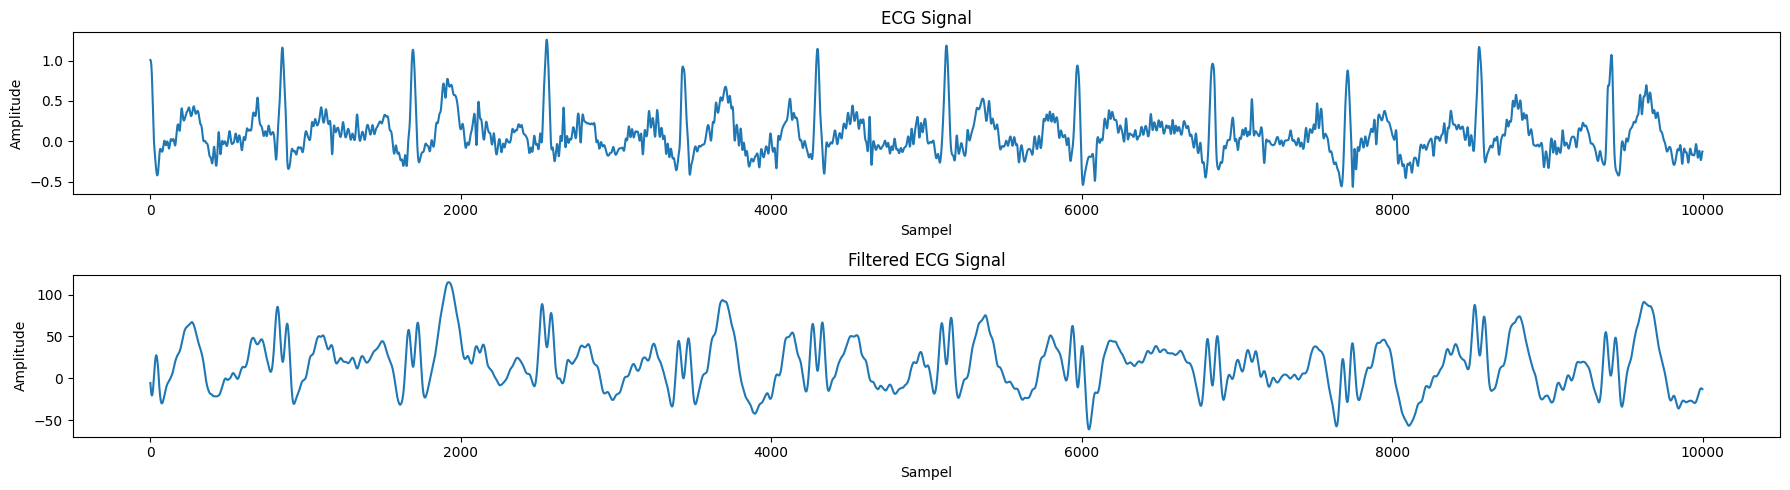

In [96]:
fig, ax = plt.subplots(2, 1, figsize=(18, 5))
ax[0].plot(ecg_signal)
ax[0].set_title('ECG Signal')
ax[0].set_xlabel('Sampel')
ax[0].set_ylabel('Amplitude')

ax[1].plot(filtered_ecg)
ax[1].set_title('Filtered ECG Signal')
ax[1].set_xlabel('Sampel')
ax[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()


In [97]:
nyquist_rata = fs/2
lowcut_nyquist = lowcut/nyquist_rata
highcut_nyquist = highcut/nyquist_rata
fft_order = 101 # filter order (luas jendela)

In [98]:
fir_coeff = firwin(
    fft_order, 
    [lowcut_nyquist, highcut_nyquist], 
    pass_zero=False
)

In [99]:
filtered_fft_scipy_ecg = filtfilt(fir_coeff, 1, ecg_signal)

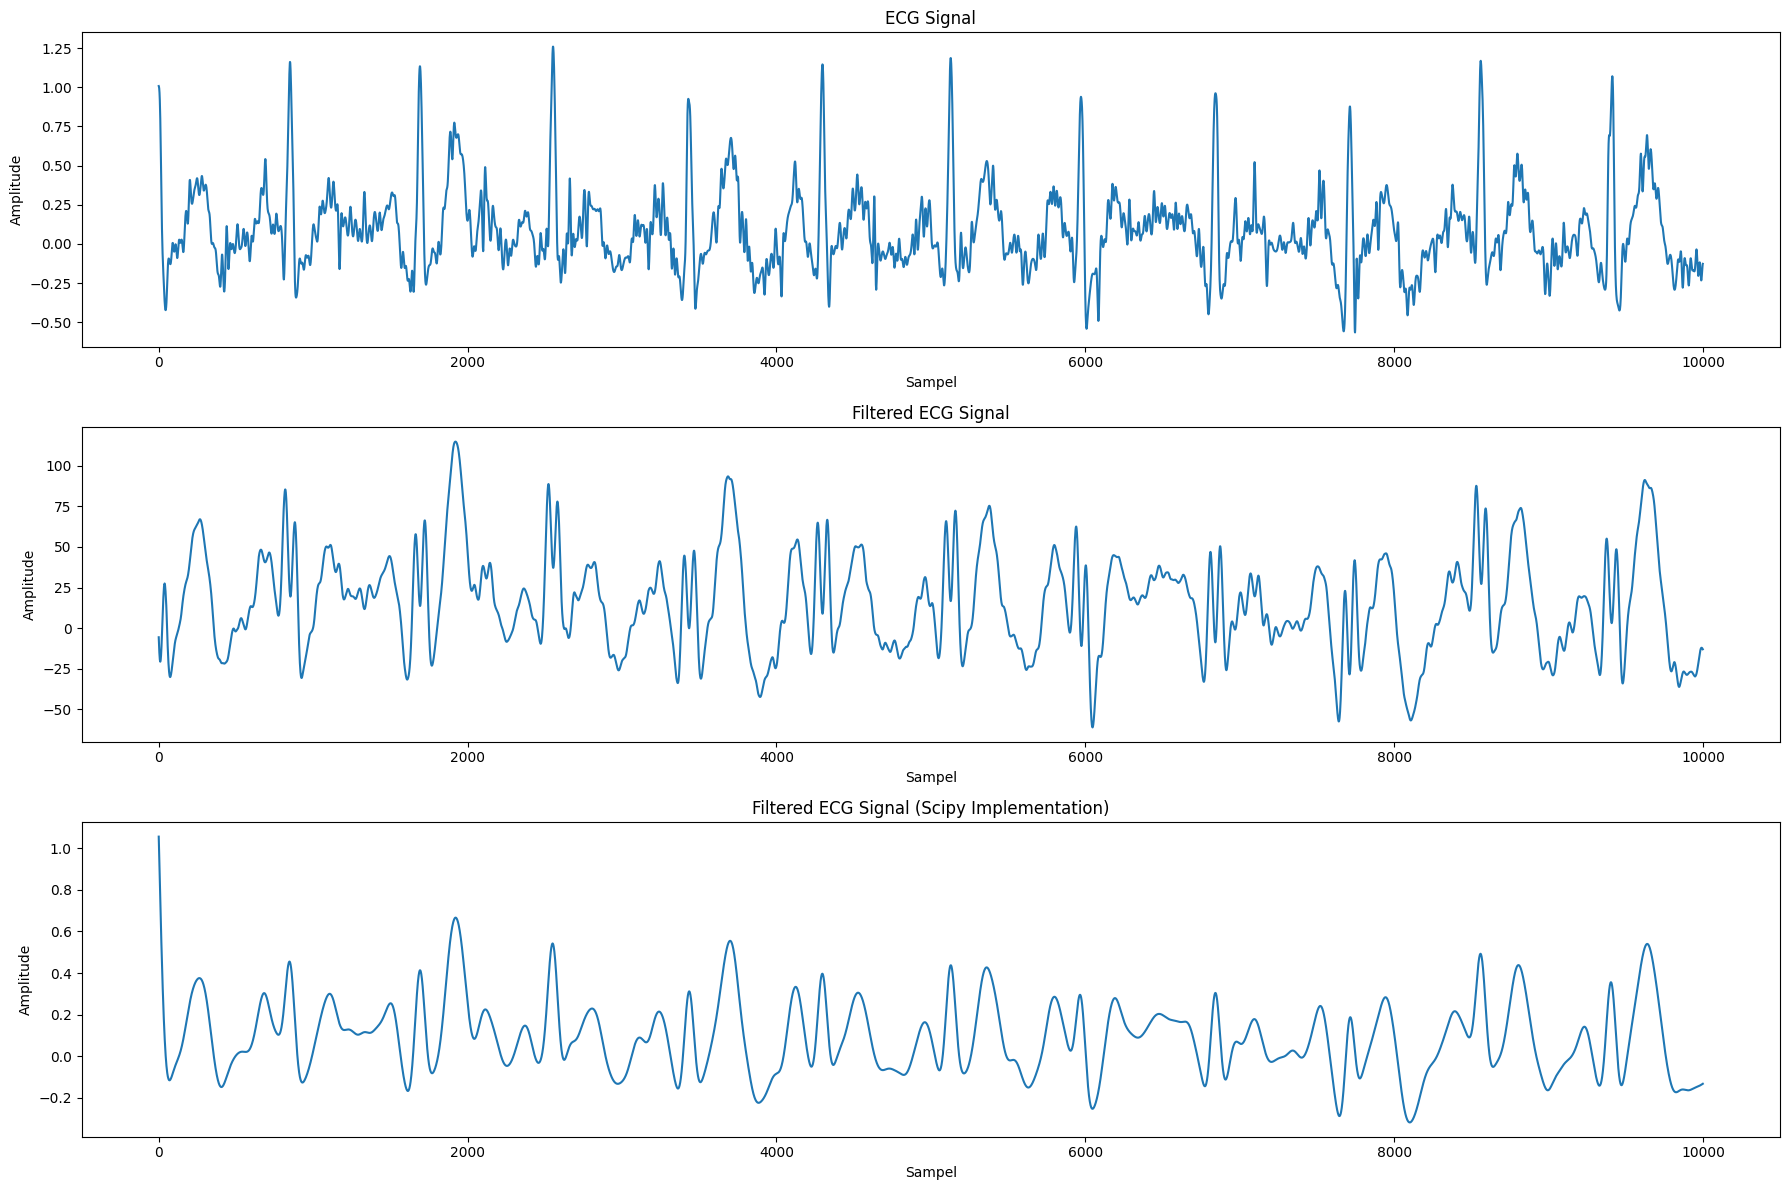

In [100]:
fig, ax = plt.subplots(3, 1, figsize=(18, 12))
ax[0].plot(ecg_signal)
ax[0].set_title('ECG Signal')
ax[0].set_xlabel('Sampel')
ax[0].set_ylabel('Amplitude')

ax[1].plot(filtered_ecg)
ax[1].set_title('Filtered ECG Signal')
ax[1].set_xlabel('Sampel')
ax[1].set_ylabel('Amplitude')

ax[2].plot(filtered_fft_scipy_ecg)
ax[2].set_title('Filtered ECG Signal (Scipy Implementation)')
ax[2].set_xlabel('Sampel')
ax[2].set_ylabel('Amplitude')  
plt.tight_layout()
plt.show()

## IIR Filter dengan Scipy

In [106]:
lowcut_iir = 0.5
highcut_iir = 4
b, a = butter(
    1, #nilai order (berapa kali dilakukan proses filtering)
    [lowcut_iir, highcut_iir],
    btype='bandpass',
    fs=fs)

waktu_mulai = dt.datetime.now()
filtered_butter_scipy_ecg = filtfilt(b, a, ecg_signal)
waktu_selesai = dt.datetime.now()
waktu_proses = waktu_selesai - waktu_mulai
print(f"Proses filtering memakan waktu {waktu_proses.total_seconds()} detik")

Proses filtering memakan waktu 0.002002 detik


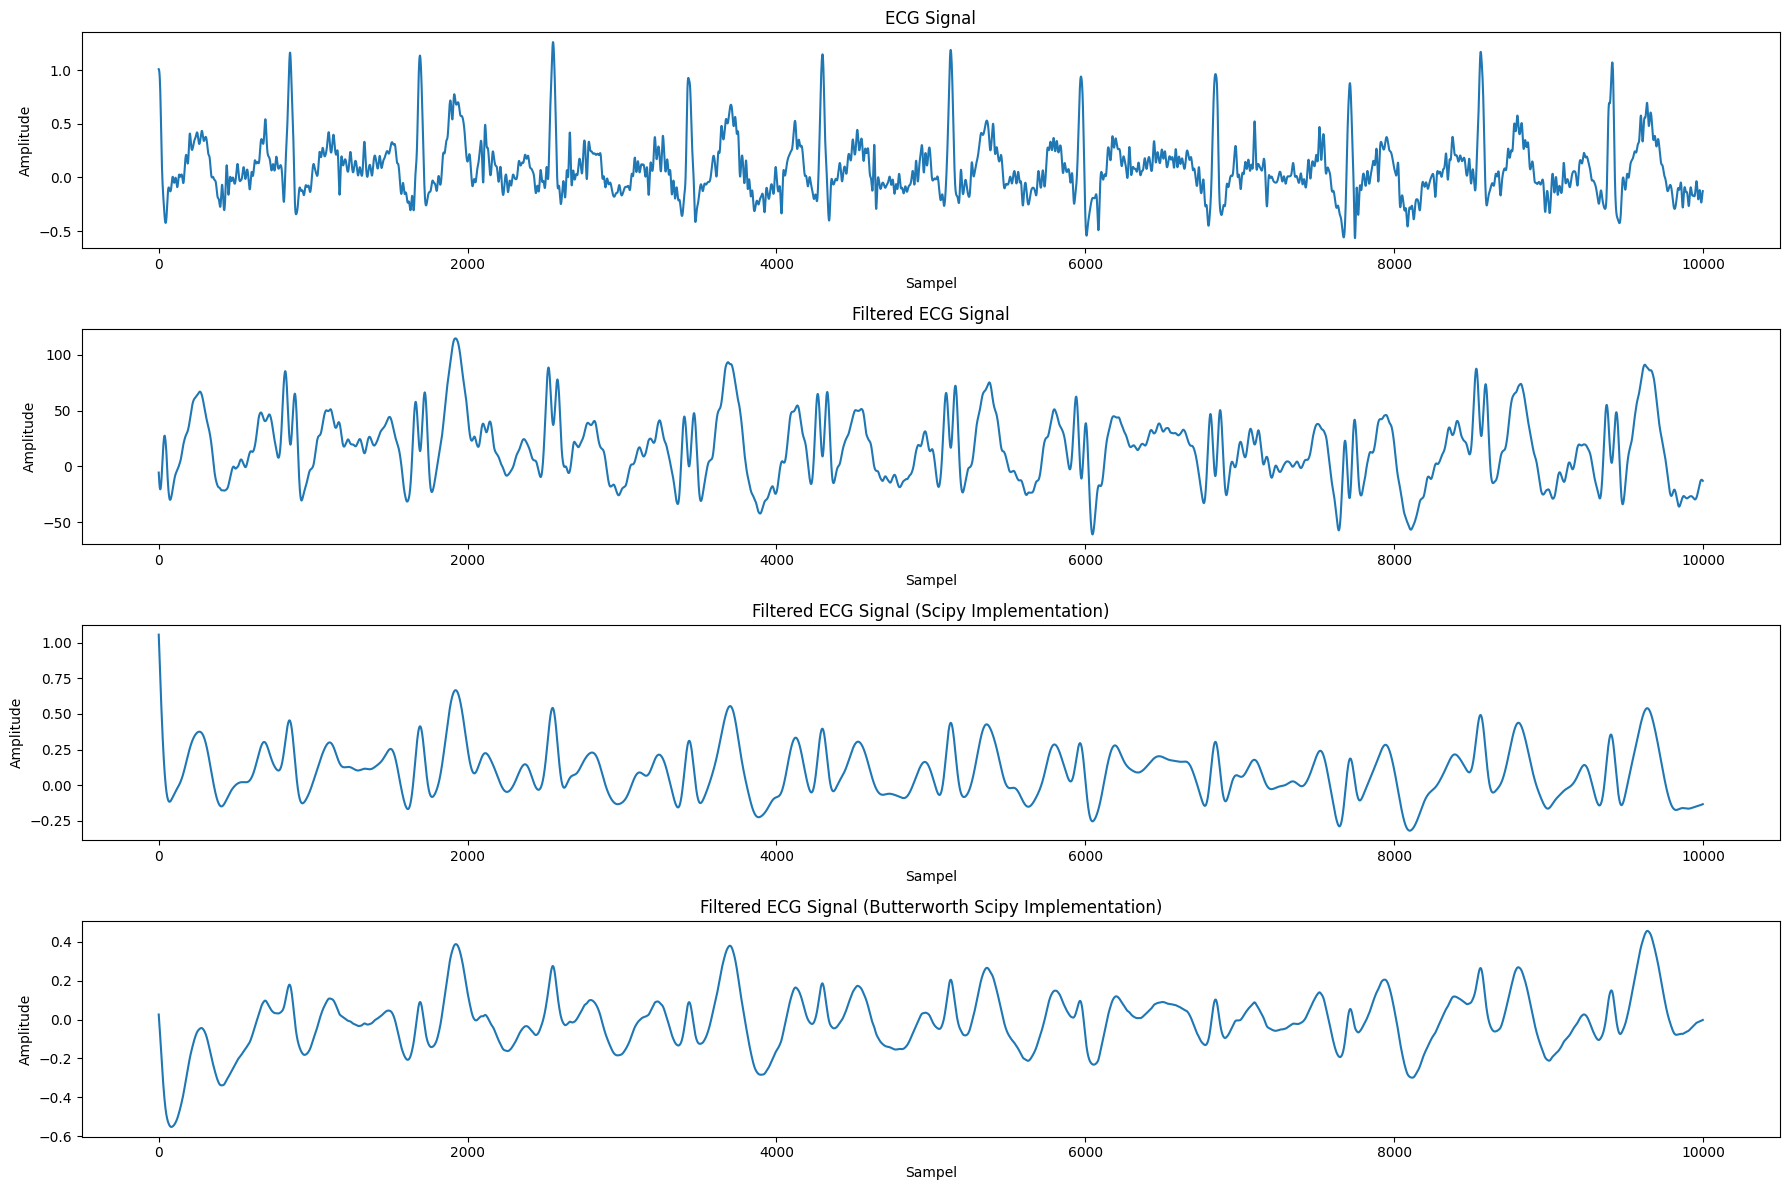

In [107]:
fig, ax = plt.subplots(4, 1, figsize=(18, 12))
ax[0].plot(ecg_signal)
ax[0].set_title('ECG Signal')
ax[0].set_xlabel('Sampel')
ax[0].set_ylabel('Amplitude')

ax[1].plot(filtered_ecg)
ax[1].set_title('Filtered ECG Signal')
ax[1].set_xlabel('Sampel')
ax[1].set_ylabel('Amplitude')

ax[2].plot(filtered_fft_scipy_ecg)
ax[2].set_title('Filtered ECG Signal (Scipy Implementation)')
ax[2].set_xlabel('Sampel')
ax[2].set_ylabel('Amplitude')  

ax[3].plot(filtered_butter_scipy_ecg)
ax[3].set_title('Filtered ECG Signal (Butterworth Scipy Implementation)')
ax[3].set_xlabel('Sampel')
ax[3].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()